#🧩 K-Means Clustering Assignment — Full Code Walkthrough

Shop Customer Segmentation using Unsupervised Machine Learning

This document explains every step of the notebook (Test_KMeans_Clustering_ShopCustomer_Data.ipynb) in plain, beginner-friendly language — perfect for submission, viva/interview explanation, or revision.



#📌 Assignment Objective

Group shop customers into meaningful segments based on their age, income, spending habits, work experience, and family size, using the K-Means Clustering algorithm — so a business can design targeted marketing strategies for each customer type.


#🗂️ Dataset Used

DetailValueFile name --> Customers.csv

Rows --> 2000 Customers

Columns--> 8

Key Column-->Age, Annual Income ($), Spending Score (1-100), Work Experience,    Family Size, Gender, Profession, CustomerID

# ── STEP 1: Import all necessary libraries ──────────────────

In [ ]:
import pandas as pd                          # for data tables
import numpy as np                           # for math/arrays
import matplotlib.pyplot as plt             # for plotting charts
import seaborn as sns                        # for pretty charts
import warnings
warnings.filterwarnings('ignore')           # hide unimportant warnings

# scikit-learn tools we need
from sklearn.cluster import KMeans          # the main algorithm
from sklearn.preprocessing import StandardScaler  # to normalize data
from sklearn.decomposition import PCA       # to reduce to 2D for plotting

 These are the standard tools for data handling (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (scikit-learn).

# ── Load the CSV file into a DataFrame ──────────────────────

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/K-Means Clustering Assignment shop customer data/Customers.csv')

Before doing anything, we load the raw CSV into a Pandas DataFrame and peek at its shape and first rows to understand what we're working with.

In [ ]:
# Quick check: how many rows and columns?
df.shape

(2000, 8)

in this dataset 8 column AND 2000 rows

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


#Explore & Understand the Data

In [ ]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income ($),int64
Spending Score (1-100),int64
Profession,object
Work Experience,int64
Family Size,int64


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income ($),0
Spending Score (1-100),0
Profession,35
Work Experience,0
Family Size,0


In [ ]:
df['Profession']

,Profession
0,Healthcare
1,Engineer
2,Engineer
3,Lawyer
4,Entertainment
...,...
1995,Artist
1996,Doctor
1997,Healthcare
1998,Executive


In [ ]:
df['Profession'].unique()

array(['Healthcare', 'Engineer', 'Lawyer', 'Entertainment', 'Artist',
       'Executive', 'Doctor', 'Homemaker', 'Marketing', nan], dtype=object)

In [ ]:
df['Profession'] = df['Profession'].fillna('no_Profession')

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income ($),0
Spending Score (1-100),0
Profession,0
Work Experience,0
Family Size,0


#This is standard EDA (Exploratory Data Analysis) — we must know the data's shape, types, and missing values before feeding it to any model.

Finding: The Profession column has missing values.


#Machine learning models can't handle NaN values, so missing professions are filled with a placeholder label "no_Profession".

In [ ]:
# CustomerID is not used because it is only an ID.
features = [
    "Age",
    "Annual Income ($)",
    "Spending Score (1-100)",
    "Work Experience",
    "Family Size",
    "Gender"
]

CustomerID is just a serial number with no analytical value, so it's dropped. Only meaningful behavioral & demographic features are kept for clustering.

In [ ]:
df = df[features].dropna()

In [ ]:
df

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size,Gender
0,19,15000,39,1,4,Male
1,21,35000,81,3,3,Male
2,20,86000,6,1,1,Female
3,23,59000,77,0,2,Female
4,31,38000,40,2,6,Female
...,...,...,...,...,...,...
1995,71,184387,40,8,7,Female
1996,91,73158,32,7,7,Female
1997,87,90961,14,9,2,Male
1998,77,182109,4,7,2,Male


#Exploratory Data Analysis

ChartPurposedf.hist()Shows the distribution of each numeric featuresns.boxplot()Detects outliers in the datasns.heatmap(df.corr())Shows correlation between features (Gender mapped to 0/1 first)sns.scatterplot(Income vs Spending, hue=Gender)Visual hint of natural groupings before clustering

Why: Visualizing data helps spot outliers, skewness, and relationships before modeling — a critical data-science habit.



df.hist() -> Shows the distribution of each numeric feature

sns.boxplot()--> Detects outliers in the data

sns.heatmap(df.corr())--> Shows correlation between features (Gender mapped to 0/1 first)

sns.scatterplot(Income vs Spending, hue=Gender)--> Visual hint of natural groupings before clustering.


#Visualizing data helps spot outliers, skewness, and relationships before modeling — a critical data-science habit.

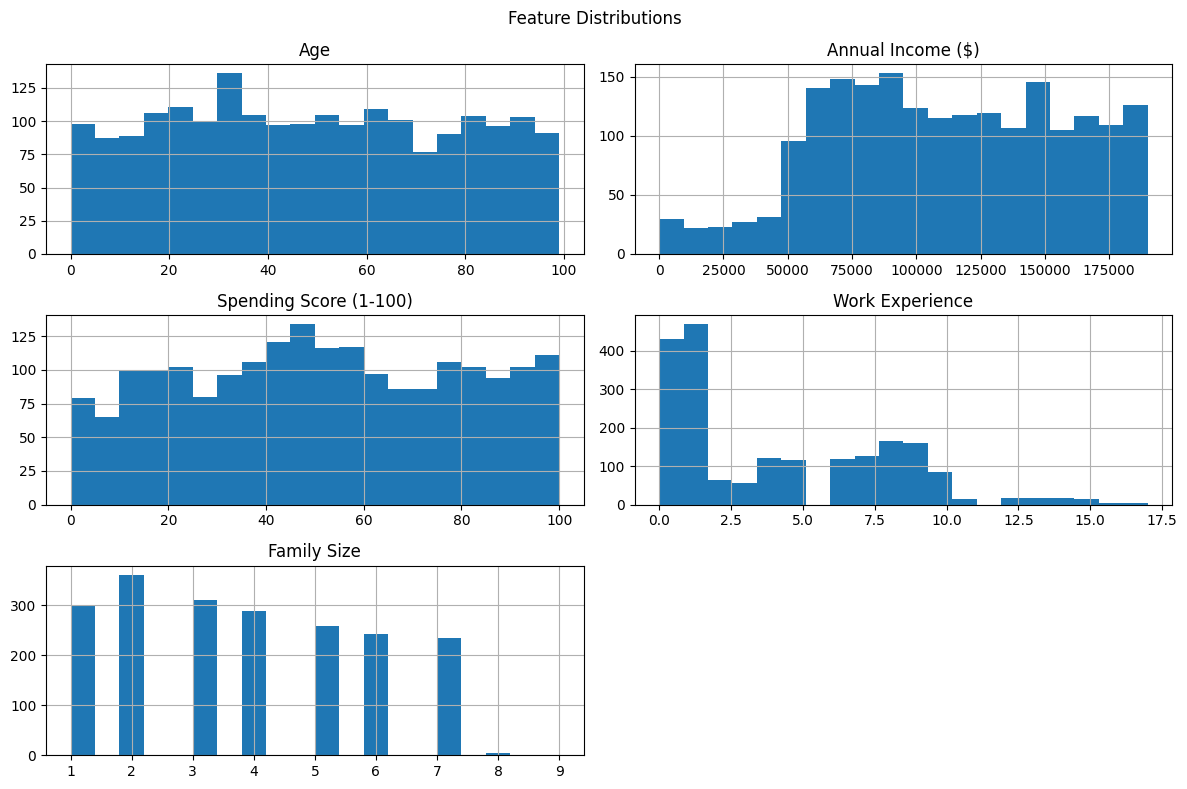

In [ ]:
df.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

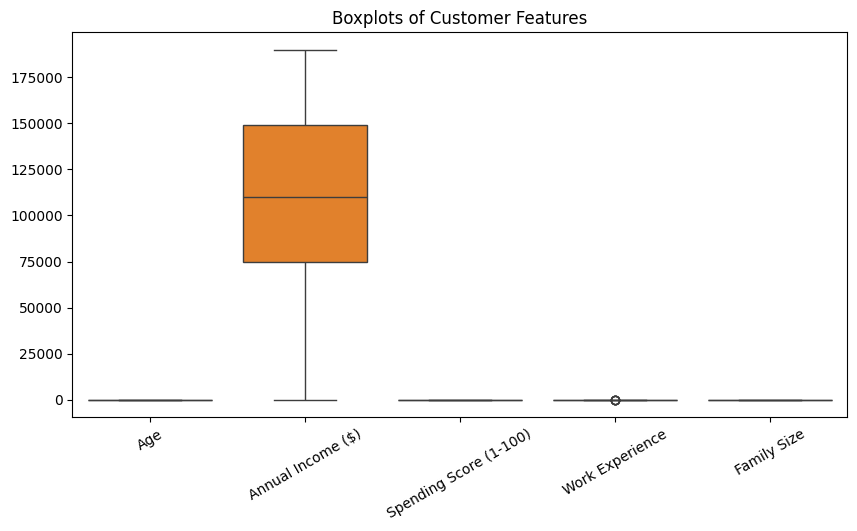

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.title("Boxplots of Customer Features")
plt.xticks(rotation=30)
plt.show()

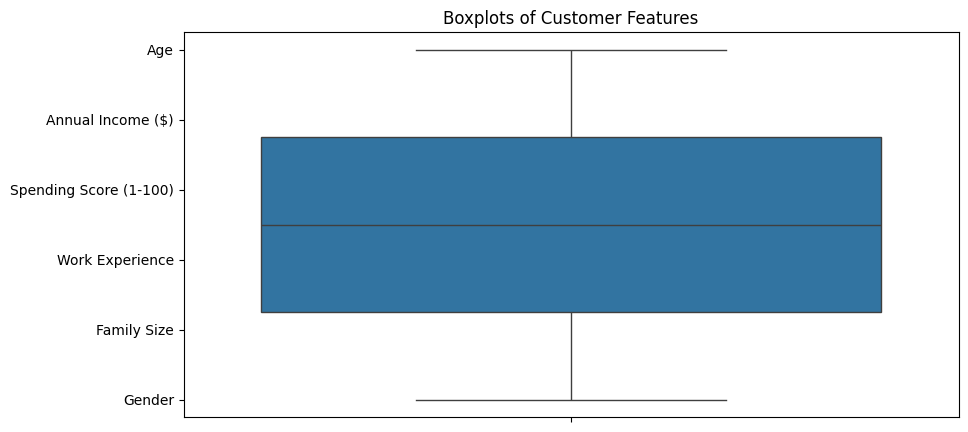

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=features)
plt.title("Boxplots of Customer Features")
plt.xticks(rotation=30)
plt.show()

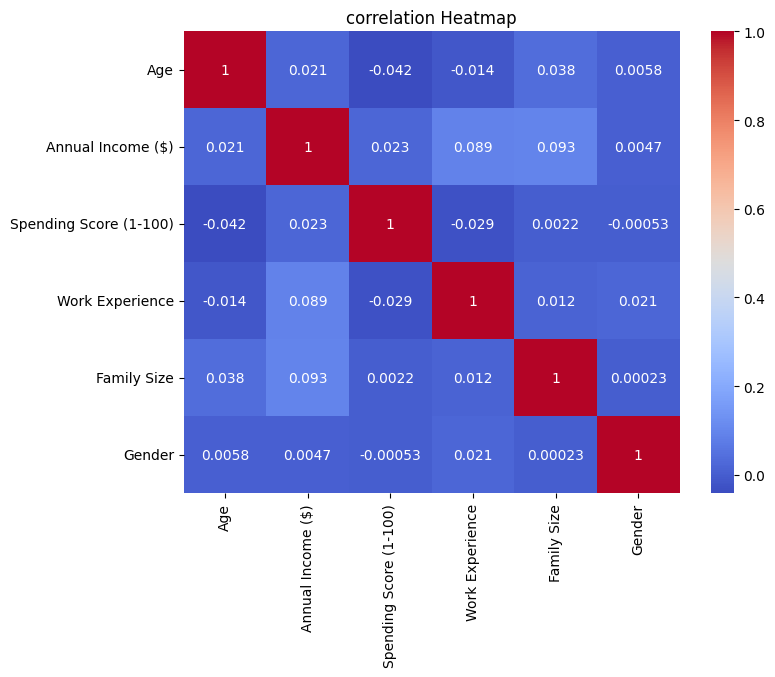

In [ ]:
plt.figure(figsize=(8,6))

# Create a copy to avoid modifying the original df for subsequent operations
df_for_corr = df.copy()

# Convert 'Gender' column to numerical representation for correlation calculation
df_for_corr['Gender'] = df_for_corr['Gender'].map({'Female': 0, 'Male': 1})

sns.heatmap(df_for_corr.corr(), annot=True, cmap='coolwarm')
plt.title("correlation Heatmap")
plt.show()

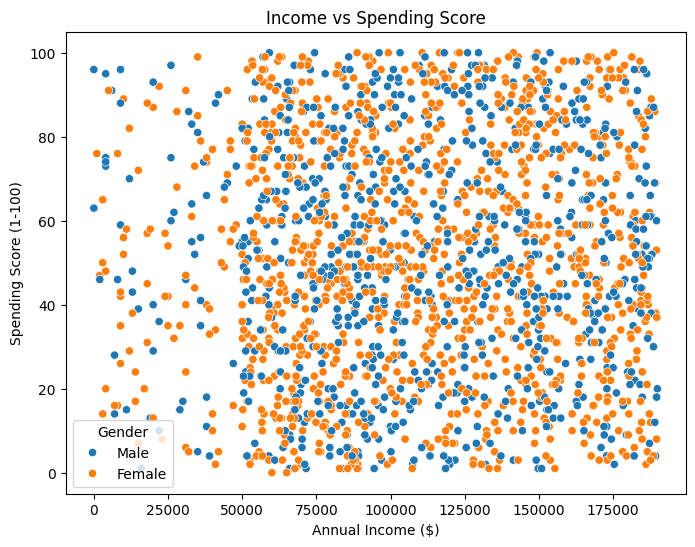

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income ($)",
    y="Spending Score (1-100)",
    hue="Gender"
)
plt.title('Income vs Spending Score')
plt.show()

#Standardize the Data

K-Means is distance-based (it uses Euclidean distance). Features like Annual Income (thousands) and Age (tens) are on very different scales — without scaling, income would dominate the clustering unfairly. StandardScaler converts every feature to mean = 0, std = 1.

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_for_corr)

#Choose Best K Using Inertia and Silhouette

In [ ]:
from sklearn.metrics import silhouette_score
k_values = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_values:
  km = KMeans(
      n_clusters=k,
      init="k-means++",
      random_state=42,
      n_init=10
  )

  km.fit(scaled_data)
  labels = km.predict(scaled_data)
  inertia.append(km.inertia_)
  silhouette_scores.append(silhouette_score(scaled_data, labels))

Two techniques are used together:


Elbow Method (Inertia) — Inertia = sum of squared distances of points to their cluster center. We look for the point where the curve "bends" like an elbow — adding more clusters beyond this gives diminishing returns.
Silhouette Score — Measures how well-separated the clusters are (ranges from -1 to 1; higher is better).

In [ ]:
silhouette_scores

[np.float64(0.17962567947526692),
 np.float64(0.1459111484044455),
 np.float64(0.15131561621753428),
 np.float64(0.14683341783012707),
 np.float64(0.14193279718153398),
 np.float64(0.14529510780574764),
 np.float64(0.1501132931049823),
 np.float64(0.15189194681808293),
 np.float64(0.15925498000467184)]

In [ ]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

print("\nK Evaluation:")
print(evaluation)


K Evaluation:
    K      Inertia  Silhouette Score
0   2  9999.034420          0.179626
1   3  9046.086420          0.145911
2   4  8398.192290          0.151316
3   5  7760.093775          0.146833
4   6  7295.382187          0.141933
5   7  6922.079973          0.145295
6   8  6530.940071          0.150113
7   9  6209.352345          0.151892
8  10  5908.432724          0.159255


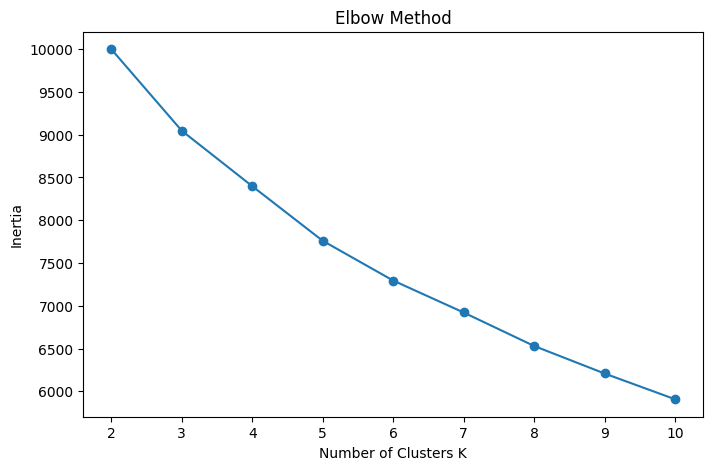

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")
plt.show()

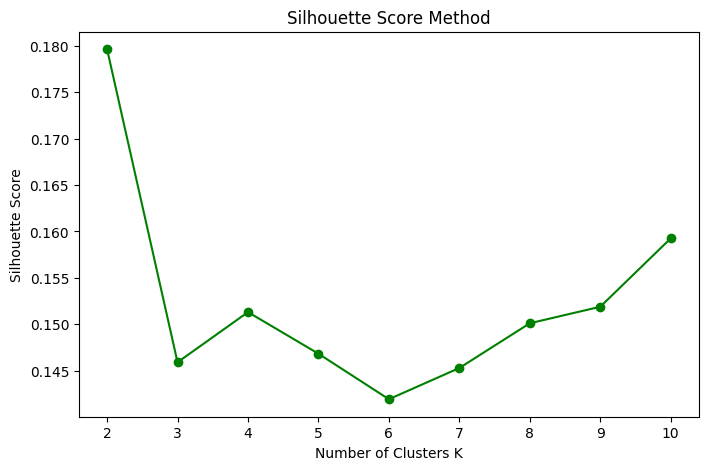

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o", color="green")
plt.title("Silhouette Score Method")
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
# Automatically choose the K with the highest silhouette score
best_k = evaluation.loc[evaluation["Silhouette Score"].idxmax(), "K"]
print("\nBest K based on silhouette score:", best_k)


Best K based on silhouette score: 2


#Why both? Elbow method can be visually ambiguous, so the Silhouette Score gives a mathematically objective second opinion.

#Apply Final K-Means Model

In [ ]:
final_kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = final_kmeans.fit_predict(scaled_data)

clustered_df = df.loc[df.index].copy()
clustered_df["Cluster"] = clusters

print("\nClustered Data:")
print(clustered_df.head())


Clustered Data:
   Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
0   19              15000                      39                1   
1   21              35000                      81                3   
2   20              86000                       6                1   
3   23              59000                      77                0   
4   31              38000                      40                2   

   Family Size  Gender  Cluster  
0            4    Male        0  
1            3    Male        0  
2            1  Female        1  
3            2  Female        1  
4            6  Female        1  


#Train final model

In [ ]:
best_k = 5
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(scaled_data)

print("\nCluster Summary:")
numerical_features = [f for f in features if f != 'Gender']
summary = df.groupby('Cluster')[numerical_features].mean().round(1)
summary['Count'] = df.groupby('Cluster').size()
print(summary)

cluster_names = {
    0: 'High-Income Young Families',
    1: 'Young Active Spenders',
    2: 'Mid-Age Experienced Savers',
    3: 'Senior Moderate Spenders',
    4: 'Low-Income Conservative'
}
df['Segment'] = df['Cluster'].map(cluster_names)


Cluster Summary:
          Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
Cluster                                                                     
0        47.1           119547.7                    50.5              8.7   
1        50.4           105746.0                    51.1              1.3   
2        22.9           137812.5                    54.5              4.1   
3        77.1           126291.0                    54.4              4.3   
4        43.6            67385.8                    44.3              3.2   

         Family Size  Count  
Cluster                      
0                3.5    345  
1                3.9    481  
2                4.4    368  
3                4.5    413  
4                2.5    393  


Based on the Elbow + Silhouette analysis, 5 clusters give the best balance of simplicity and separation.

Each customer now gets a Cluster label (0–4).

#Visualize Final Clusters

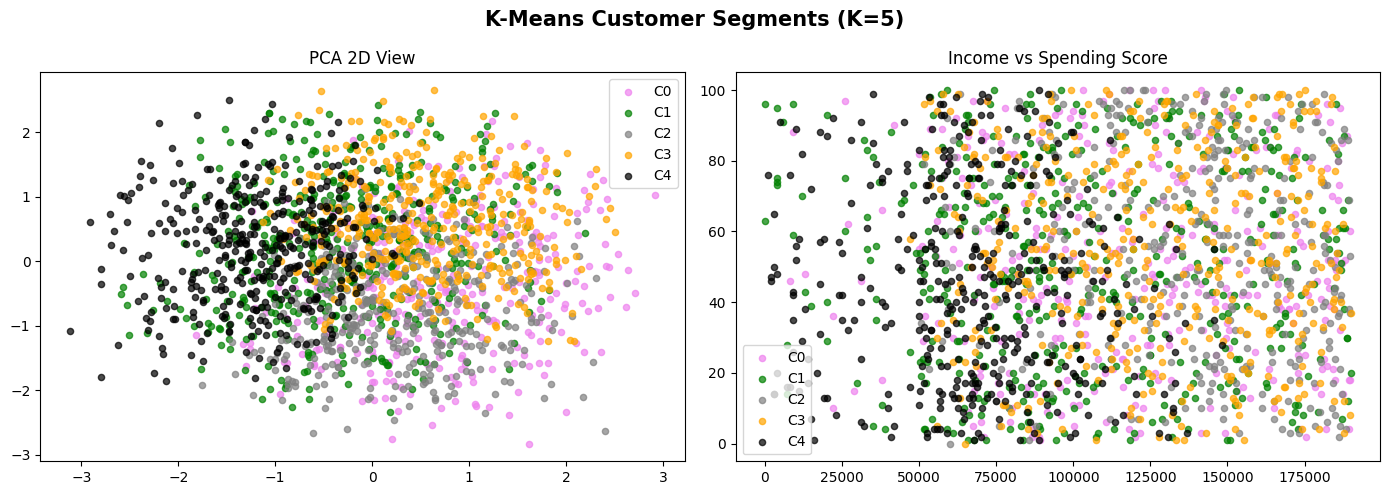

In [ ]:
colors = ['violet', 'green', 'gray', 'orange', 'black']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

for i in range(best_k):
    mask = df['Cluster'] == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                  c=colors[i], s=20, alpha=0.7, label=f'C{i}')
    axes[1].scatter(df.loc[mask, 'Annual Income ($)'],
                  df.loc[mask, 'Spending Score (1-100)'],
                  c=colors[i], s=20, alpha=0.7, label=f'C{i}')

axes[0].set_title('PCA 2D View'); axes[0].legend()
axes[1].set_title('Income vs Spending Score'); axes[1].legend()
plt.suptitle('K-Means Customer Segments (K=5)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

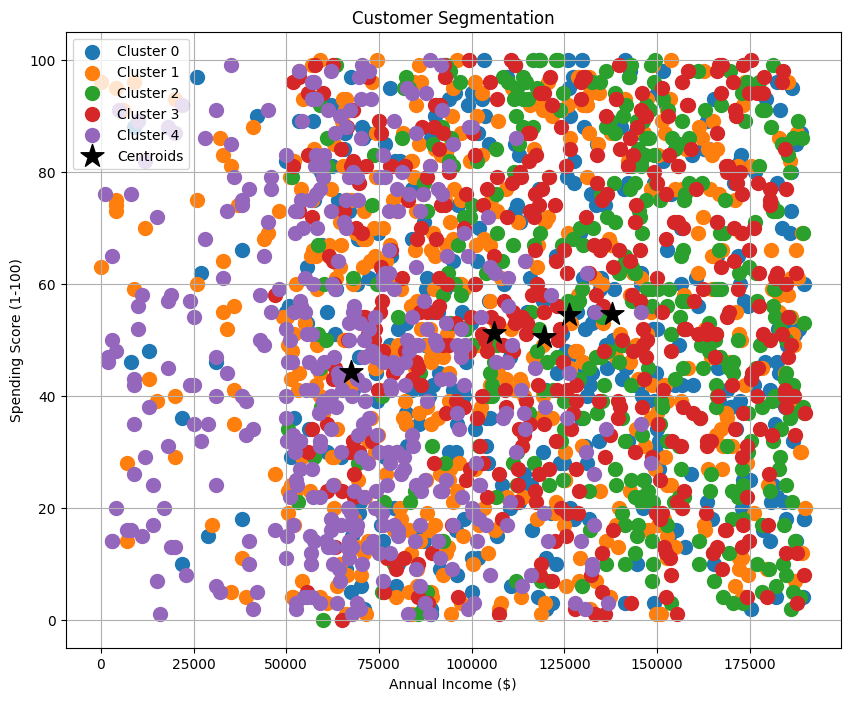

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(best_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income ($)'], cluster_data['Spending Score (1-100)'],
                s=100, label=f'Cluster {i}')

# Get scaled centroids for 'Annual Income ($)' (index 1) and 'Spending Score (1-100)' (index 2)
scaled_income_centroids = km_final.cluster_centers_[:, 1]
scaled_spending_centroids = km_final.cluster_centers_[:, 2]

# Inverse transform to original scale
original_income_centroids = (scaled_income_centroids * scaler.scale_[1]) + scaler.mean_[1]
original_spending_centroids = (scaled_spending_centroids * scaler.scale_[2]) + scaler.mean_[2]

plt.scatter(original_income_centroids, original_spending_centroids,
            s=300, c='BLACK', marker='*', edgecolor='black', label='Centroids')
plt.title('Customer Segmentation')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

Raw cluster numbers (0,1,2,3,4) mean nothing to a business stakeholder. Translating them into human-readable personas makes the analysis actionable.

In [ ]:
km_final.cluster_centers_

array([[-0.0650726 ,  0.18997392, -0.01937105,  1.18447546, -0.12004698,
         1.10647099],
       [ 0.04892658, -0.10639544,  0.0059486 , -0.70231964,  0.07432424,
         1.20706357],
       [-0.91593781,  0.59221129,  0.12744487, -0.01089389,  0.3161033 ,
        -0.82845678],
       [ 0.9916489 ,  0.340255  ,  0.12315515,  0.05536858,  0.36328355,
        -0.82352816],
       [-0.18748987, -0.94790712, -0.23910019, -0.22340907, -0.66384285,
        -0.80773902]])

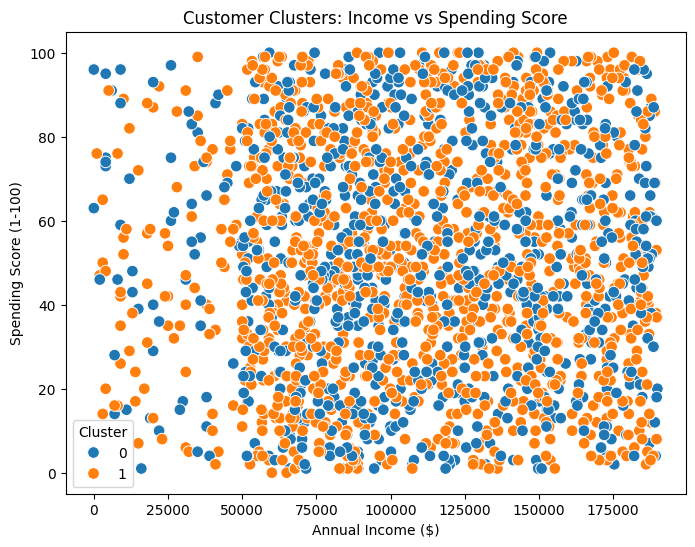

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=clustered_df,
    x="Annual Income ($)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=70
)
plt.title("Customer Clusters: Income vs Spending Score")
plt.show()

#Visualize the Clusters

PCA 2D Scatter Plot-->Compresses all features into 2 dimensions so all 5 clusters can be seen on one chart

Income vs Spending Score Scatter-->The classic, most intuitive cluster view

Centroid Plot-->Shows the "center point" (average customer) of each cluster, converted back to original scale



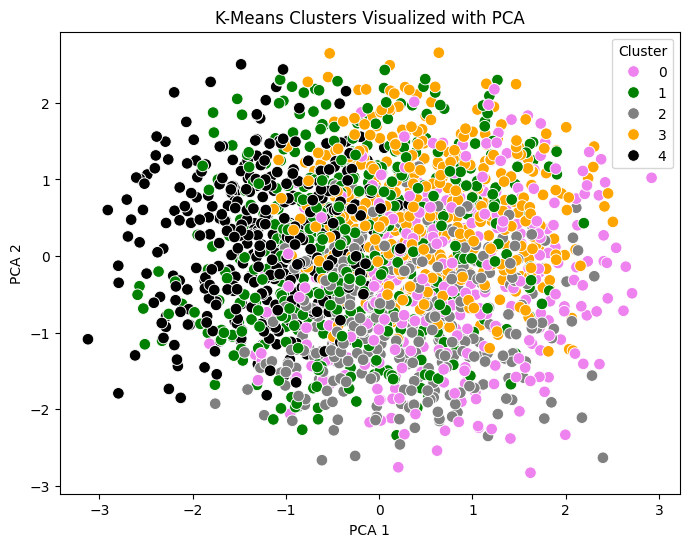

In [ ]:
# PCA helps visualize all selected features in 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=["PCA 1", "PCA 2"])
pca_df["Cluster"] = df['Cluster']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PCA 1",
    y="PCA 2",
    hue="Cluster",
    palette=colors,
    s=70
)
plt.title("K-Means Clusters Visualized with PCA")
plt.show()

We clustered on 6 dimensions, but humans can only visually interpret 2D/3D plots. Principal Component Analysis (PCA) compresses the data while preserving as much variance (information) as possible.

#Analyze the Clusters

In [ ]:
print("\nNumber of customers in each cluster:")
print(clustered_df["Cluster"].value_counts().sort_index())

print("\nAverage values for each cluster:")
numerical_features = [f for f in features if f != 'Gender']
cluster_summary = clustered_df.groupby("Cluster")[numerical_features].mean().round(2)
print(cluster_summary)


Number of customers in each cluster:
Cluster
0     814
1    1186
Name: count, dtype: int64

Average values for each cluster:
           Age  Annual Income ($)  Spending Score (1-100)  Work Experience  \
Cluster                                                                      
0        49.16          110991.32                   50.94             4.20   
1        48.82          110553.72                   50.97             4.04   

         Family Size  
Cluster               
0               3.77  
1               3.77  


#Save Clustered Output

In [ ]:
clustered_df.to_csv("customers_with_kmeans_clusters.csv", index=False)
print("\nClustered file saved as customers_with_kmeans_clusters.csv")


Clustered file saved as customers_with_kmeans_clusters.csv


We compute the average Age, Income, Spending Score, Work Experience, and Family Size per cluster — this is what turns clusters into real business insight ("Cluster 1 = young, high spenders").

## 🧠 Key Machine Learning Concepts Used

| Concept | Role in this Project |
|---|---|
| **Unsupervised Learning** | No labels given — the model discovers groups on its own |
| **K-Means Clustering** | Partitions data into K clusters by minimizing within-cluster variance |
| **StandardScaler** | Normalizes features so no single column dominates distance calculations |
| **Elbow Method** | Helps visually pick optimal K using Inertia |
| **Silhouette Score** | Numerically validates cluster quality/separation |
| **PCA (Principal Component Analysis)** | Reduces dimensions for visualization |
| **Centroid** | The "average" data point representing each cluster's center |

---

## ✅ Summary

| Step | Task |
|---|---|
| 1 | Import libraries |
| 2 | Load dataset |
| 3 | Explore data (shape, types, nulls) |
| 4 | Clean missing values |
| 5 | Select features |
| 6 | Visual EDA (histograms, boxplots, heatmap) |
| 7 | Standardize data |
| 8 | Find optimal K (Elbow + Silhouette) |
| 9 | Train final K-Means model (K=5) |
| 10 | Name customer segments |
| 11 | Visualize clusters (PCA + scatter plots) |
| 12 | Analyze cluster averages |
| 13 | Export results to CSV |